### Step 1:Import Libraries

In [1]:
# Step 2: Load Dataset

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Step 2: Load Dataset

In [4]:
df = pd.read_csv("diabetes_final.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Senior
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Middle Age
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Middle Age
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Young
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Middle Age


In [6]:
# Step 3: Define Features and Target
# Features (X)

In [7]:
X = df.drop("Outcome", axis=1)

In [8]:
## Since Age_Group was created from the existing Age column, it doesn't add much new information. Simply remove it from your features:

In [9]:
X = df.drop(columns=['Outcome', 'Age_Group'])
y = df['Outcome']

In [10]:
## Target (y)

In [11]:
y = df["Outcome"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
## Check shapes

In [14]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [15]:
## Step 5: Train Logistic Regression

In [16]:
## Create model:

In [17]:
lr_model = LogisticRegression(max_iter=1000)

In [18]:
## Train:

In [19]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [21]:
## Step 6: Make Predictions

In [22]:
lr_predictions = lr_model.predict(X_test)

In [23]:
## Step 7: Evaluate Logistic Regression

In [24]:
# Accuracy

In [25]:
accuracy_score(y_test, lr_predictions)

0.7532467532467533

In [26]:
## Confusion Matrix

In [27]:
confusion_matrix(
    y_test,
    lr_predictions
)

array([[82, 17],
       [21, 34]])

In [28]:
## Classification Report

In [29]:
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [30]:
# Step 8: Train Random Forest

In [31]:
# Random Forest often performs better.
# Create model:

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [33]:
# Train:

In [34]:
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
## Step 9: Predict

In [36]:
rf_predictions = rf_model.predict(X_test)

In [37]:
## Step 10: Evaluate Random Forest

In [38]:
## Accuracy

In [39]:
accuracy_score(
    y_test,
    rf_predictions
)

0.7467532467532467

In [40]:
## Confusion Matrix

In [41]:
confusion_matrix(
    y_test,
    rf_predictions
)

array([[78, 21],
       [18, 37]])

In [42]:
# Classification Report

In [43]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [44]:
## Step 11: Feature Importance

In [45]:
## One of the most important analyses.

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Glucose,0.263453
5,BMI,0.164118
7,Age,0.134927
6,DiabetesPedigreeFunction,0.121819
4,Insulin,0.089248
2,BloodPressure,0.084062
3,SkinThickness,0.072432
0,Pregnancies,0.069942


In [47]:
## Visualization

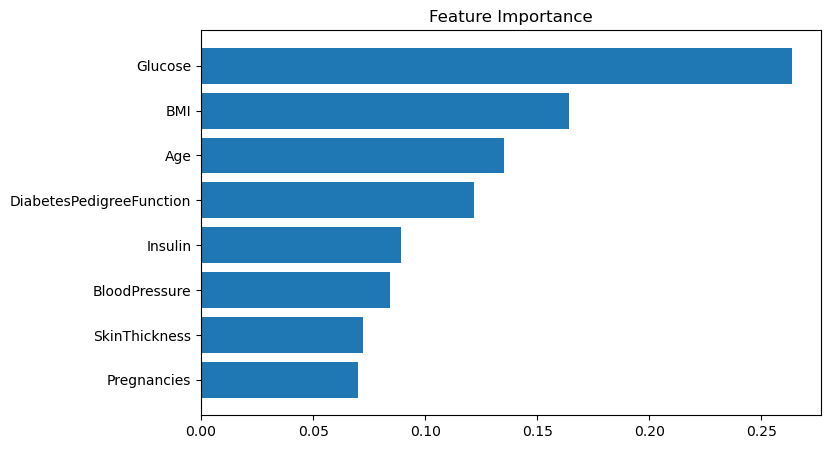

In [48]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [49]:
## Step 12: Compare Models

In [54]:
print(
    "Logistic Regression:",
    accuracy_score(y_test, lr_predictions)
)

print(
    "Random Forest:",
    accuracy_score(y_test, rf_predictions)
)

Logistic Regression: 0.7532467532467533
Random Forest: 0.7467532467532467


In [51]:
## Evaluate the models further:

In [52]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_lr = lr_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[82 17]
 [21 34]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

